# UAS Deep Learning
Nomor 1 (LSTM Time Series Prediction)

Name: Syaqila Najwa Amalia Hambali

NIM: 2802488481

## Video Explanation

Link video explanation: https://youtu.be/7netmugwSJ8?si=mfETwFyQmllSkDjC


## 1a. Data Exploration and Preprocessing

Pada bagian ini dilakukan eksplorasi dan preprocessing data saham sebelum digunakan pada model LSTM. Dataset yang digunakan terdiri dari dua data time series saham, yaitu FB dan IBM. Karena data saham merupakan data time series, maka urutan tanggal harus dipertahankan dan data tidak boleh diacak.

Sesuai instruksi soal, kolom yang digunakan adalah Date dan Close. Kolom Date digunakan sebagai penanda waktu perdagangan, sedangkan kolom Close digunakan sebagai harga penutupan yang akan diprediksi oleh model.

Data test diambil dari periode satu tahun terakhir. Data sebelum periode test digunakan sebagai training data, kemudian training data tersebut dibagi kembali menjadi 90% train set dan 10% validation set. Pembagian dilakukan secara manual berdasarkan urutan waktu agar tidak terjadi data leakage.

Setelah itu, data diubah menjadi bentuk supervised learning menggunakan window size sebesar 5 dan horizon sebesar 1. Artinya, harga penutupan selama 5 hari sebelumnya digunakan sebagai input untuk memprediksi harga penutupan pada 1 hari berikutnya.

In [1]:
# import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load Dataset

fb = pd.read_csv("FB.csv")
ibm = pd.read_csv("IBM.csv")

print("FB dataset shape:", fb.shape)
print("IBM dataset shape:", ibm.shape)

display(fb.head())
display(ibm.head())

FB dataset shape: (1980, 7)
IBM dataset shape: (14663, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200


,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,7.713333,7.713333,7.626667,7.626667,0.618153,387200
1,1962-01-03,7.626667,7.693333,7.626667,7.693333,0.623556,288000
2,1962-01-04,7.693333,7.693333,7.613333,7.616667,0.617343,256000
3,1962-01-05,7.606667,7.606667,7.453333,7.466667,0.605185,363200
4,1962-01-08,7.460000,7.460000,7.266667,7.326667,0.593837,544000


Berdasarkan hasil load dataset, data saham FB memiliki 1.980 baris dan 7 kolom, sedangkan data saham IBM memiliki 14.663 baris dan 7 kolom. Kedua dataset memiliki struktur kolom yang sama, yaitu Date, Open, High, Low, Close, Adj Close, dan Volume.

Namun, sesuai instruksi soal, kolom yang digunakan untuk membangun model LSTM hanya Date dan Close. Kolom Date digunakan untuk menjaga urutan waktu, sedangkan kolom Close digunakan sebagai nilai harga penutupan yang akan diprediksi.

In [3]:
# Cek Struktur Data

print("FB Dataset Information")
fb.info()

print("\nIBM Dataset Information")
ibm.info()

FB Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1980 non-null   str    
 1   Open       1980 non-null   float64
 2   High       1980 non-null   float64
 3   Low        1980 non-null   float64
 4   Close      1980 non-null   float64
 5   Adj Close  1980 non-null   float64
 6   Volume     1980 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 127.7 KB

IBM Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 14663 entries, 0 to 14662
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       14663 non-null  str    
 1   Open       14663 non-null  float64
 2   High       14663 non-null  float64
 3   Low        14663 non-null  float64
 4   Close      14663 non-null  float64
 5   Adj Close  14663 non-null  float64
 6   Volume     1466

In [4]:
# Check Missing Values

print("Missing values in FB dataset:")
display(fb.isnull().sum())

print("Missing values in IBM dataset:")
display(ibm.isnull().sum())

Missing values in FB dataset:


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Missing values in IBM dataset:


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Berdasarkan hasil pengecekan struktur data, dataset FB dan IBM memiliki kolom yang sama. Kolom Date masih bertipe object/string sehingga perlu diubah menjadi format datetime. Kolom Close sudah bertipe numerik sehingga dapat digunakan untuk proses normalisasi dan pembuatan data sequence LSTM.

Berdasarkan hasil pengecekan missing value, tidak terdapat nilai kosong pada dataset FB maupun IBM. Oleh karena itu, tidak diperlukan proses imputasi pada tahap preprocessing.

In [5]:
# Select Date and Close Columns

fb_stock = fb[["Date", "Close"]].copy()
ibm_stock = ibm[["Date", "Close"]].copy()

fb_stock["Date"] = pd.to_datetime(fb_stock["Date"])
ibm_stock["Date"] = pd.to_datetime(ibm_stock["Date"])

fb_stock = fb_stock.sort_values("Date").reset_index(drop=True)
ibm_stock = ibm_stock.sort_values("Date").reset_index(drop=True)

display(fb_stock.head())
display(ibm_stock.head())

,Date,Close
0,2012-05-18,38.230000
1,2012-05-21,34.029999
2,2012-05-22,31.000000
3,2012-05-23,32.000000
4,2012-05-24,33.029999


,Date,Close
0,1962-01-02,7.626667
1,1962-01-03,7.693333
2,1962-01-04,7.616667
3,1962-01-05,7.466667
4,1962-01-08,7.326667


Pada tahap ini, hanya kolom Date dan Close yang dipilih dari dataset FB dan IBM. Kolom Date diubah menjadi format datetime agar dapat diproses sebagai data time series, kemudian data diurutkan berdasarkan tanggal. Kolom Close digunakan sebagai variabel utama karena harga penutupan menjadi nilai yang akan diprediksi oleh model LSTM.

In [6]:
# Check Date Range

print("FB date range:")
print(fb_stock["Date"].min(), "to", fb_stock["Date"].max())

print("\nIBM date range:")
print(ibm_stock["Date"].min(), "to", ibm_stock["Date"].max())

FB date range:
2012-05-18 00:00:00 to 2020-04-01 00:00:00

IBM date range:
1962-01-02 00:00:00 to 2020-04-01 00:00:00


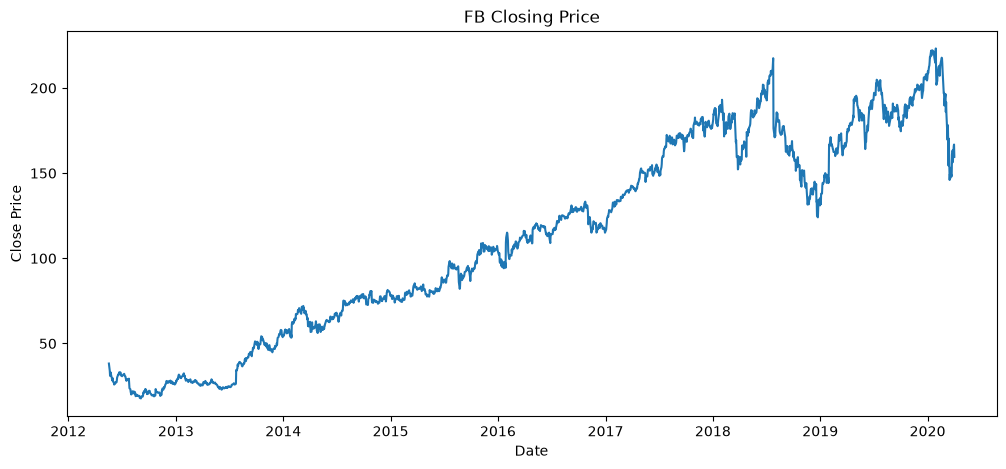

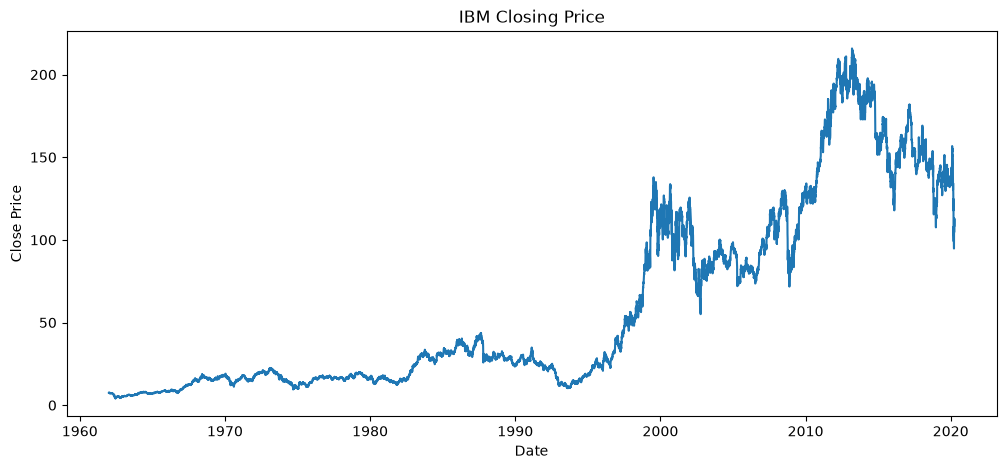

In [7]:
# Visualize Closing Price

plt.figure(figsize=(12, 5))
plt.plot(fb_stock["Date"], fb_stock["Close"])
plt.title("FB Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(ibm_stock["Date"], ibm_stock["Close"])
plt.title("IBM Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

Berdasarkan hasil pengecekan periode data, saham FB memiliki data dari 18 Mei 2012 sampai 1 April 2020, sedangkan saham IBM memiliki data dari 2 Januari 1962 sampai 1 April 2020. Perbedaan periode ini menunjukkan bahwa jumlah data IBM jauh lebih banyak dibandingkan FB.

Visualisasi harga penutupan menunjukkan bahwa kedua saham memiliki pola pergerakan harga yang berubah dari waktu ke waktu. Saham FB cenderung mengalami kenaikan harga sejak awal periode hingga sekitar tahun 2018–2020, meskipun terdapat beberapa penurunan tajam. Sementara itu, saham IBM memiliki histori yang lebih panjang dan menunjukkan beberapa fase kenaikan serta penurunan harga yang cukup besar.

Karena data memiliki urutan waktu, proses pembagian data tidak dilakukan secara acak. Data satu tahun terakhir digunakan sebagai test set karena merepresentasikan periode masa depan yang ingin diprediksi. Sementara itu, data sebelum periode test digunakan sebagai training data, kemudian dibagi kembali menjadi train set dan validation set.

In [8]:
# Create LSTM Dataset with Window Size 5 and One-Year Test Set

def create_lstm_dataset(stock_data, window_size=5):
    stock_data = stock_data.copy()
    stock_data["Date"] = pd.to_datetime(stock_data["Date"])
    stock_data = stock_data.sort_values("Date").reset_index(drop=True)

    # Test set uses the last one-year period
    test_start_date = stock_data["Date"].max() - pd.DateOffset(years=1)

    # Target date starts after window size
    target_dates = stock_data["Date"].iloc[window_size:].reset_index(drop=True)

    # Count train-validation and test samples based on target date
    train_val_count = (target_dates < test_start_date).sum()
    train_count = int(train_val_count * 0.9)

    # Fit MinMaxScaler only on train set to avoid data leakage
    train_last_raw_index = window_size + train_count - 1

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(stock_data.loc[:train_last_raw_index, ["Close"]])

    close_scaled = scaler.transform(stock_data[["Close"]])

    X = []
    y = []

    for i in range(window_size, len(close_scaled)):
        X.append(close_scaled[i-window_size:i, 0])
        y.append(close_scaled[i, 0])

    X = np.array(X)
    y = np.array(y)

    X = X.reshape(X.shape[0], X.shape[1], 1)

    X_train = X[:train_count]
    y_train = y[:train_count]

    X_val = X[train_count:train_val_count]
    y_val = y[train_count:train_val_count]

    X_test = X[train_val_count:]
    y_test = y[train_val_count:]

    split_info = pd.DataFrame({
        "Split": ["Train", "Validation", "Test"],
        "Start Date": [
            target_dates.iloc[0],
            target_dates.iloc[train_count],
            target_dates.iloc[train_val_count]
        ],
        "End Date": [
            target_dates.iloc[train_count - 1],
            target_dates.iloc[train_val_count - 1],
            target_dates.iloc[-1]
        ],
        "Samples": [
            len(X_train),
            len(X_val),
            len(X_test)
        ]
    })

    return scaler, X_train, X_val, X_test, y_train, y_val, y_test, split_info

In [9]:
# Apply Preprocessing to FB and IBM

window_size = 5

fb_scaler, X_train_fb, X_val_fb, X_test_fb, y_train_fb, y_val_fb, y_test_fb, fb_split_info = create_lstm_dataset(
    fb_stock, window_size
)

ibm_scaler, X_train_ibm, X_val_ibm, X_test_ibm, y_train_ibm, y_val_ibm, y_test_ibm, ibm_split_info = create_lstm_dataset(
    ibm_stock, window_size
)

print("FB X_train shape:", X_train_fb.shape)
print("FB X_val shape  :", X_val_fb.shape)
print("FB X_test shape :", X_test_fb.shape)
print("FB y_train shape:", y_train_fb.shape)
print("FB y_val shape  :", y_val_fb.shape)
print("FB y_test shape :", y_test_fb.shape)

print("\nIBM X_train shape:", X_train_ibm.shape)
print("IBM X_val shape  :", X_val_ibm.shape)
print("IBM X_test shape :", X_test_ibm.shape)
print("IBM y_train shape:", y_train_ibm.shape)
print("IBM y_val shape  :", y_val_ibm.shape)
print("IBM y_test shape :", y_test_ibm.shape)

FB X_train shape: (1548, 5, 1)
FB X_val shape  : (173, 5, 1)
FB X_test shape : (254, 5, 1)
FB y_train shape: (1548,)
FB y_val shape  : (173,)
FB y_test shape : (254,)

IBM X_train shape: (12963, 5, 1)
IBM X_val shape  : (1441, 5, 1)
IBM X_test shape : (254, 5, 1)
IBM y_train shape: (12963,)
IBM y_val shape  : (1441,)
IBM y_test shape : (254,)


In [10]:
print("\nFB Split Information")
display(fb_split_info)

print("\nIBM Split Information")
display(ibm_split_info)


FB Split Information


,Split,Start Date,End Date,Samples
0,Train,2012-05-25,2018-07-20,1548
1,Validation,2018-07-23,2019-03-29,173
2,Test,2019-04-01,2020-04-01,254



IBM Split Information


,Split,Start Date,End Date,Samples
0,Train,1962-01-09,2013-07-09,12963
1,Validation,2013-07-10,2019-03-29,1441
2,Test,2019-04-01,2020-04-01,254


Setelah dilakukan normalisasi dan pembuatan sequence, data berhasil diubah menjadi format yang sesuai untuk input LSTM, yaitu tiga dimensi dengan bentuk (samples, timesteps, features). Nilai timesteps adalah 5 karena window size yang digunakan sebesar 5, sedangkan features bernilai 1 karena hanya kolom Close yang digunakan.

Berdasarkan hasil split data, test set diambil dari periode satu tahun terakhir, yaitu 1 April 2019 sampai 1 April 2020. Hal ini sesuai dengan instruksi soal yang menyatakan bahwa data test harus mencakup periode satu tahun terakhir.

Pada saham FB, data dibagi menjadi 1.548 sequence untuk train set, 173 sequence untuk validation set, dan 254 sequence untuk test set. Pada saham IBM, data dibagi menjadi 12.963 sequence untuk train set, 1.441 sequence untuk validation set, dan 254 sequence untuk test set. Jumlah data train dan validation IBM lebih besar karena histori data IBM jauh lebih panjang dibandingkan FB.

Pembagian data dilakukan secara manual berdasarkan urutan waktu dan tidak diacak karena dataset merupakan data time series. Data sebelum periode test digunakan sebagai training data, kemudian training data tersebut dibagi kembali menjadi 90% train set dan 10% validation set. Train set digunakan untuk melatih model, validation set digunakan untuk memantau performa selama training, sedangkan test set digunakan untuk evaluasi akhir menggunakan RMSE, MAE, dan MAPE.

Tanggal awal train set tidak dimulai dari tanggal pertama pada dataset karena data sudah diubah menjadi sequence dengan window size sebesar 5. Artinya, lima data pertama digunakan sebagai input awal untuk memprediksi target pertama atau horizon 1.

In [11]:
# Check MinMax Scaling Result

def check_minmax_scaling(stock_data, scaler, stock_name):
    scaled_close = scaler.transform(stock_data[["Close"]])
    
    summary = pd.DataFrame({
        "Stock": [stock_name],
        "Original Close Min": [stock_data["Close"].min()],
        "Original Close Max": [stock_data["Close"].max()],
        "Scaled Close Min": [scaled_close.min()],
        "Scaled Close Max": [scaled_close.max()]
    })
    
    return summary

fb_minmax_summary = check_minmax_scaling(fb_stock, fb_scaler, "FB")
ibm_minmax_summary = check_minmax_scaling(ibm_stock, ibm_scaler, "IBM")

minmax_summary = pd.concat([fb_minmax_summary, ibm_minmax_summary], ignore_index=True)
minmax_summary

,Stock,Original Close Min,Original Close Max,Scaled Close Min,Scaled Close Max
0,FB,17.73,223.229996,0.0,1.068865
1,IBM,4.08,215.800003,0.0,1.000000


### MinMax Scaling Result

Pada tahap preprocessing, nilai Close dinormalisasi menggunakan MinMaxScaler. Scaler hanya di-fit pada train set untuk menghindari data leakage, sehingga informasi dari validation set dan test set tidak digunakan dalam proses fitting scaler.

Karena scaler hanya mempelajari nilai minimum dan maksimum dari train set, nilai pada validation set atau test set dapat berada di luar rentang 0 sampai 1 apabila harga pada periode tersebut lebih tinggi atau lebih rendah dibandingkan rentang harga pada train set. Hal ini masih wajar dan lebih aman dibandingkan melakukan fitting scaler pada seluruh dataset, karena fitting pada seluruh dataset dapat menyebabkan data leakage.

Pada saham FB, nilai scaled close maksimum melebihi 1 karena scaler hanya di-fit pada train set. Jika terdapat harga pada validation atau test set yang lebih tinggi dari maksimum train set, hasil transformasi dapat menjadi lebih besar dari 1. Hal ini tidak menjadi masalah karena scaler memang hanya menggunakan informasi dari train set untuk menghindari data leakage.

## 1b. Baseline LSTM Model

Pada bagian ini dibuat model baseline LSTM untuk memprediksi harga penutupan saham FB dan IBM. Model baseline digunakan sebagai model awal yang nantinya akan dibandingkan dengan modified LSTM pada bagian berikutnya.

Sesuai instruksi soal, arsitektur baseline menggunakan satu layer LSTM dengan 50 units dan activation function ReLU. Layer akhir menggunakan satu node Perceptron atau Dense layer dengan 1 unit karena model hanya memprediksi satu nilai, yaitu harga Close pada hari berikutnya.

Model dilatih menggunakan train set dan dipantau menggunakan validation set. Test set tidak digunakan pada tahap training karena test set hanya digunakan untuk evaluasi akhir pada bagian 1d.

In [12]:
# Import Deep Learning Libraries

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

In [13]:
# Build Baseline LSTM Model

def build_baseline_lstm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(LSTM(units=50, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

Arsitektur baseline LSTM terdiri dari beberapa komponen utama:

- LSTM(units=50, activation="relu") digunakan untuk mempelajari pola historis dari data time series.
- Dense(1) digunakan sebagai output layer karena model hanya memprediksi satu nilai, yaitu harga Close pada hari berikutnya.
- Loss function yang digunakan adalah MSE karena permasalahan ini merupakan regresi.
- Optimizer yang digunakan adalah Adam dengan learning rate 0.001.

In [14]:
# Baseline LSTM for FB

baseline_fb = build_baseline_lstm((X_train_fb.shape[1], X_train_fb.shape[2]))
baseline_fb.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Model baseline FB dilatih menggunakan X_train_fb dan y_train_fb. Validation set digunakan untuk memantau performa model selama training. Test set tidak digunakan pada tahap ini agar evaluasi akhir tetap objektif.

Model dilatih selama 50 epoch dengan batch size 32. Nilai loss yang digunakan adalah MSE, sehingga semakin kecil nilai loss menunjukkan bahwa prediksi model semakin mendekati nilai aktual pada skala data yang sudah dinormalisasi.

In [15]:
# Train Baseline LSTM for FB

history_baseline_fb = baseline_fb.fit(
    X_train_fb,
    y_train_fb,
    validation_data=(X_val_fb, y_val_fb),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1123 - val_loss: 0.0012
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0050 - val_loss: 0.0022
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4408e-04 - val_loss: 0.0020
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7118e-04 - val_loss: 0.0016
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2551e-04 - val_loss: 0.0014
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0055e-04 - val_loss: 0.0013
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9760e-04 - val_loss: 0.0013
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9603e-04 - val_loss: 0.0013
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9565e-04 - val_loss: 0.0013
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9557e-04 - val_loss: 0.0013
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9566e-04 - val_loss: 0.0013
Epoch 12/50
49/49 ━━━━━━━━━━━━━━━━━━━

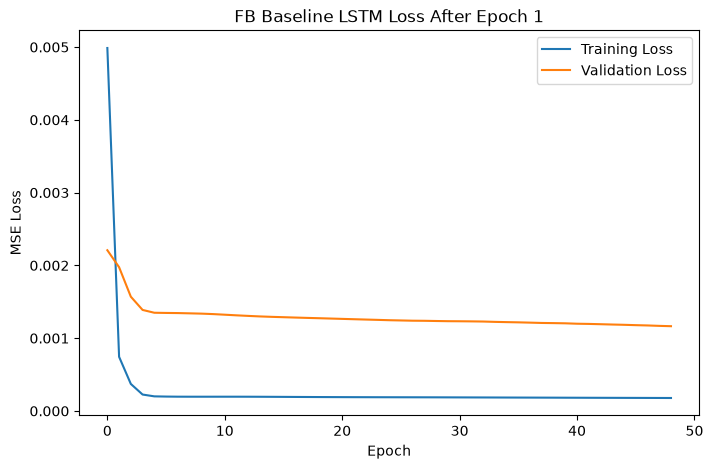

In [16]:
# Plot Training and Validation Loss for FB Baseline Model

plt.figure(figsize=(8, 5))
plt.plot(history_baseline_fb.history["loss"][1:], label="Training Loss")
plt.plot(history_baseline_fb.history["val_loss"][1:], label="Validation Loss")
plt.title("FB Baseline LSTM Loss After Epoch 1")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Berdasarkan grafik loss baseline LSTM pada saham FB, training loss mengalami penurunan tajam pada epoch awal, kemudian mulai stabil pada nilai yang rendah. Validation loss juga mengalami penurunan, meskipun nilainya masih lebih tinggi dibandingkan training loss.

Pada hasil akhir, baseline LSTM untuk saham FB memperoleh final training loss sebesar 0.000178 dan final validation loss sebesar 0.001165. Perbedaan antara training loss dan validation loss menunjukkan adanya gap generalisasi, tetapi model masih dapat digunakan sebagai baseline karena validation loss tetap berada pada nilai yang rendah.

Hasil ini digunakan sebagai pembanding awal sebelum dilakukan modifikasi arsitektur LSTM.

In [17]:
# Baseline LSTM for IBM

baseline_ibm = build_baseline_lstm((X_train_ibm.shape[1], X_train_ibm.shape[2]))

baseline_ibm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Model baseline IBM dilatih menggunakan X_train_ibm dan y_train_ibm. Validation set digunakan untuk memantau performa model selama training, sedangkan test set tetap disimpan untuk evaluasi akhir.

Arsitektur baseline IBM sama seperti baseline FB, yaitu menggunakan satu layer LSTM dengan 50 units dan satu Dense output layer. Hal ini dilakukan agar baseline model pada kedua saham memiliki struktur yang konsisten dan dapat dibandingkan dengan modified model.

In [18]:
# Train Baseline LSTM for IBM

history_baseline_ibm = baseline_ibm.fit(
    X_train_ibm,
    y_train_ibm,
    validation_data=(X_val_ibm, y_val_ibm),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0090 - val_loss: 1.7033e-04
Epoch 2/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4232e-05 - val_loss: 1.6367e-04
Epoch 3/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3199e-05 - val_loss: 1.5938e-04
Epoch 4/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2596e-05 - val_loss: 1.5566e-04
Epoch 5/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2056e-05 - val_loss: 1.5234e-04
Epoch 6/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1381e-05 - val_loss: 1.4884e-04
Epoch 7/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0727e-05 - val_loss: 1.4585e-04
Epoch 8/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9882e-05 - val_loss: 1.4240e-04
Epoch 9/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8888e-05 - val_loss: 1.3814e-04
Epoch 10/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.7702e-05 - val_loss: 1.3381e-04
Epoch 11/50
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.

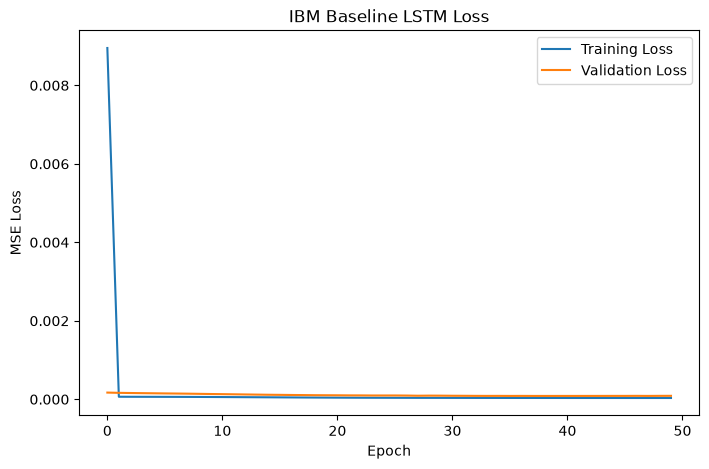

In [19]:
# Plot Training and Validation Loss for IBM Baseline Model

plt.figure(figsize=(8, 5))
plt.plot(history_baseline_ibm.history["loss"], label="Training Loss")
plt.plot(history_baseline_ibm.history["val_loss"], label="Validation Loss")
plt.title("IBM Baseline LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Berdasarkan grafik loss baseline LSTM pada saham IBM, training loss mengalami penurunan yang cukup besar pada epoch awal, kemudian mulai stabil pada nilai yang rendah. Validation loss juga menunjukkan tren penurunan secara bertahap selama proses training.

Pada hasil akhir, baseline LSTM untuk saham IBM memperoleh final training loss sebesar 0.000032 dan final validation loss sebesar 0.000087. Nilai validation loss masih lebih tinggi dibandingkan training loss, tetapi keduanya berada pada nilai yang relatif kecil. Hal ini menunjukkan bahwa baseline LSTM mampu mempelajari pola historis harga saham IBM dengan cukup baik.

Hasil baseline IBM ini digunakan sebagai pembanding awal sebelum dilakukan modifikasi arsitektur LSTM.

In [20]:
# Baseline Loss Summary

baseline_loss_summary = pd.DataFrame({
    "Stock": ["FB", "IBM"],
    "Final Training Loss": [
        history_baseline_fb.history["loss"][-1],
        history_baseline_ibm.history["loss"][-1]
    ],
    "Final Validation Loss": [
        history_baseline_fb.history["val_loss"][-1],
        history_baseline_ibm.history["val_loss"][-1]
    ]
})

baseline_loss_summary

,Stock,Final Training Loss,Final Validation Loss
0,FB,0.000178,0.001165
1,IBM,0.000032,0.000087


Berdasarkan baseline loss summary, model baseline LSTM pada saham FB memperoleh final training loss sebesar 0.000178 dan final validation loss sebesar 0.001165. Validation loss yang lebih tinggi dibandingkan training loss menunjukkan adanya gap antara performa model pada train set dan validation set.

Pada saham IBM, model baseline memperoleh final training loss sebesar 0.000032 dan final validation loss sebesar 0.000087. Nilai validation loss masih lebih tinggi dibandingkan training loss, tetapi gap-nya lebih kecil dibandingkan FB. Hal ini menunjukkan bahwa baseline LSTM pada saham IBM memiliki kemampuan generalisasi yang cukup stabil pada validation set.

Secara keseluruhan, baseline LSTM berhasil dibangun dan dilatih untuk dua saham, yaitu FB dan IBM. Kedua model menggunakan arsitektur yang sama, yaitu satu layer LSTM dengan 50 units dan satu output neuron. Model baseline ini kemudian digunakan sebagai pembanding terhadap modified LSTM pada bagian berikutnya.

## 1c. Modified LSTM Architecture

Pada bagian ini dilakukan modifikasi terhadap arsitektur baseline LSTM untuk mencoba meningkatkan performa model. Baseline sebelumnya menggunakan satu layer LSTM dengan 50 units, activation function ReLU, dan satu output neuron. Pada model modifikasi, arsitektur dibuat lebih kompleks dengan menambahkan jumlah units, Dropout, Dense layer tambahan, learning rate yang lebih kecil, dan EarlyStopping.

Modifikasi ini dilakukan karena pada baseline model masih terdapat gap antara training loss dan validation loss, terutama pada saham FB. Dropout digunakan untuk membantu mengurangi risiko overfitting, sedangkan learning rate yang lebih kecil digunakan agar proses training lebih stabil. EarlyStopping digunakan agar training dapat berhenti ketika validation loss tidak lagi membaik.

Model modified tetap dilatih menggunakan train set dan dipantau menggunakan validation set. Test set tidak digunakan pada tahap training karena test set hanya digunakan untuk evaluasi akhir pada bagian 1d.

In [21]:
# Additional Import for Modified LSTM

from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
# Build Modified LSTM Model

def build_modified_lstm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    model.add(LSTM(units=64, activation="relu"))
    model.add(Dropout(0.2))
    
    model.add(Dense(16, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="mse"
    )

    return model

In [23]:
# Modified LSTM for FB

modified_fb = build_modified_lstm((X_train_fb.shape[1], X_train_fb.shape[2]))

modified_fb.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,953 (70.13 KB)

 Trainable params: 17,953 (70.13 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Early Stopping for FB

early_stop_fb = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [25]:
# Train Modified LSTM for FB

history_modified_fb = modified_fb.fit(
    X_train_fb,
    y_train_fb,
    validation_data=(X_val_fb, y_val_fb),
    epochs=70,
    batch_size=32,
    callbacks=[early_stop_fb],
    verbose=1
)

Epoch 1/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1398 - val_loss: 0.1055
Epoch 2/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0169 - val_loss: 0.0031
Epoch 3/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0046 - val_loss: 0.0012
Epoch 4/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - val_loss: 0.0011
Epoch 5/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 6/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - val_loss: 0.0012
Epoch 7/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 0.0012
Epoch 8/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 9/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 10/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 11/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 12/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - val_l

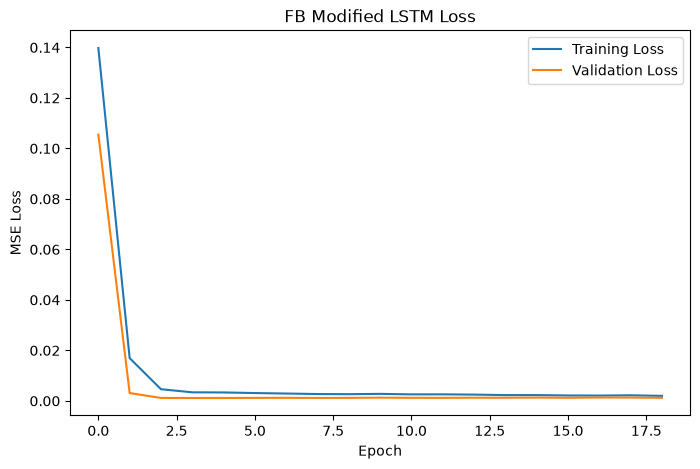

In [26]:
# Plot Training and Validation Loss for FB Modified Model

plt.figure(figsize=(8, 5))
plt.plot(history_modified_fb.history["loss"], label="Training Loss")
plt.plot(history_modified_fb.history["val_loss"], label="Validation Loss")
plt.title("FB Modified LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Berdasarkan grafik loss modified LSTM pada saham FB, training loss dan validation loss mengalami penurunan tajam pada epoch awal. Model menggunakan EarlyStopping, sehingga training berhenti pada epoch ke-19 ketika validation loss tidak lagi menunjukkan perbaikan yang signifikan.

Pada hasil akhir, modified LSTM untuk saham FB memperoleh final training loss sebesar 0.001991 dan final validation loss sebesar 0.001213. Nilai training loss dan validation loss relatif dekat, sehingga model tidak menunjukkan gap generalisasi yang terlalu besar.

Namun, hasil modified LSTM pertama belum cukup kuat untuk dipilih sebagai model terbaik. Oleh karena itu, dilakukan tuning lanjutan dengan membangun Modified LSTM V2.

In [27]:
# Modified LSTM for IBM

modified_ibm = build_modified_lstm((X_train_ibm.shape[1], X_train_ibm.shape[2]))

modified_ibm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,953 (70.13 KB)

 Trainable params: 17,953 (70.13 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Early Stopping Callback for IBM

early_stop_ibm = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [29]:
# Train Modified LSTM for IBM

history_modified_ibm = modified_ibm.fit(
    X_train_ibm,
    y_train_ibm,
    validation_data=(X_val_ibm, y_val_ibm),
    epochs=70,
    batch_size=32,
    callbacks=[early_stop_ibm],
    verbose=1
)

Epoch 1/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0140 - val_loss: 2.4306e-04
Epoch 2/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0010 - val_loss: 5.3141e-04
Epoch 3/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7.5717e-04 - val_loss: 2.9253e-04
Epoch 4/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.1353e-04 - val_loss: 2.0749e-04
Epoch 5/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.5364e-04 - val_loss: 5.0552e-04
Epoch 6/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.8287e-04 - val_loss: 4.0971e-04
Epoch 7/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.3190e-04 - val_loss: 2.1472e-04
Epoch 8/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.9632e-04 - val_loss: 4.6971e-04
Epoch 9/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.7389e-04 - val_loss: 2.2838e-04
Epoch 10/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.3736e-04 - val_loss: 3.0782e-04
Epoch 11/70
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2205

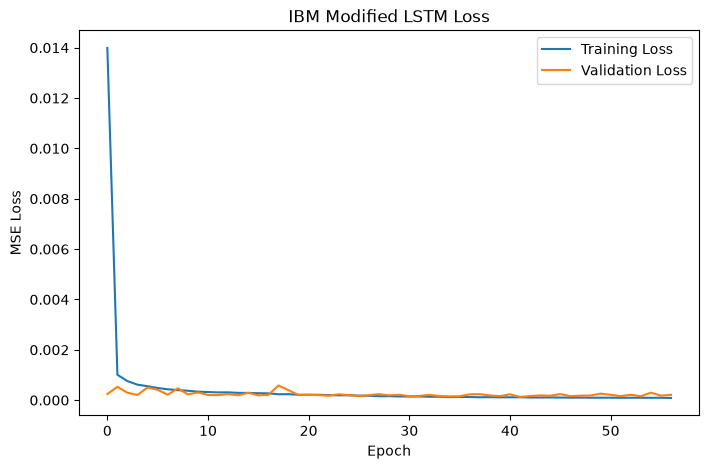

In [30]:
# Plot Training and Validation Loss for IBM Modified Model

plt.figure(figsize=(8, 5))
plt.plot(history_modified_ibm.history["loss"], label="Training Loss")
plt.plot(history_modified_ibm.history["val_loss"], label="Validation Loss")
plt.title("IBM Modified LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Berdasarkan grafik loss modified LSTM pada saham IBM, training loss mengalami penurunan selama proses training. Hal ini menunjukkan bahwa model mampu mempelajari pola dari train set. Namun, validation loss terlihat lebih fluktuatif dan tidak selalu mengikuti penurunan training loss.

Model menggunakan epoch maksimum sebesar 70 dan EarlyStopping. Pada proses training, model berhenti pada epoch ke-57 karena validation loss tidak lagi menunjukkan perbaikan yang signifikan setelah beberapa epoch. Dengan restore_best_weights=True, model tetap menggunakan bobot terbaik berdasarkan validation loss.

Fluktuasi validation loss menunjukkan bahwa modified LSTM pada saham IBM kurang stabil dibandingkan baseline model. Oleh karena itu, model ini tetap perlu dibandingkan secara objektif dengan baseline dan Modified LSTM V2 menggunakan RMSE, MAE, dan MAPE pada test set.

In [31]:
# Modified Model Loss Summary

modified_loss_summary = pd.DataFrame({
    "Stock": ["FB", "IBM"],
    "Final Training Loss": [
        history_modified_fb.history["loss"][-1],
        history_modified_ibm.history["loss"][-1]
    ],
    "Final Validation Loss": [
        history_modified_fb.history["val_loss"][-1],
        history_modified_ibm.history["val_loss"][-1]
    ],
    "Epochs Used": [
        len(history_modified_fb.history["loss"]),
        len(history_modified_ibm.history["loss"])
    ]
})

modified_loss_summary

,Stock,Final Training Loss,Final Validation Loss,Epochs Used
0,FB,0.001991,0.001213,19
1,IBM,0.000086,0.000209,57


Berdasarkan modified loss summary, modified LSTM pada saham FB memperoleh final training loss sebesar 0.001991 dan final validation loss sebesar 0.001213. Model berhenti pada epoch ke-19 karena menggunakan EarlyStopping. Nilai training loss dan validation loss relatif masih dekat, sehingga modified model pada saham FB tidak menunjukkan gap yang terlalu besar antara train set dan validation set.

Pada saham IBM, modified LSTM memperoleh final training loss sebesar 0.000086 dan final validation loss sebesar 0.000209. Model berhenti pada epoch ke-57 karena validation loss tidak lagi membaik setelah beberapa epoch. Validation loss yang lebih tinggi dibandingkan training loss menunjukkan bahwa model modified IBM masih memiliki gap generalisasi, meskipun nilainya tidak sebesar interpretasi sebelumnya.

Secara keseluruhan, modified LSTM berhasil dibangun untuk saham FB dan IBM dengan meningkatkan jumlah LSTM units, menambahkan Dropout, menambahkan Dense layer tambahan, menggunakan learning rate yang lebih kecil, serta menerapkan EarlyStopping. Namun, hasil modified LSTM pertama belum cukup kuat untuk dipilih sebagai model terbaik, sehingga dilakukan tuning lanjutan melalui Modified LSTM V2.

In [32]:
# Validation Evaluation Function
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_lstm_on_validation(model, X_val, y_val, scaler):
    y_pred_scaled = model.predict(X_val)
    
    y_actual = scaler.inverse_transform(y_val.reshape(-1, 1))
    y_pred = scaler.inverse_transform(y_pred_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
    
    return rmse, mae, mape

In [33]:
# Baseline vs Modified LSTM Validation Evaluation

fb_baseline_val_rmse, fb_baseline_val_mae, fb_baseline_val_mape = evaluate_lstm_on_validation(
    baseline_fb, X_val_fb, y_val_fb, fb_scaler
)

fb_modified_val_rmse, fb_modified_val_mae, fb_modified_val_mape = evaluate_lstm_on_validation(
    modified_fb, X_val_fb, y_val_fb, fb_scaler
)

ibm_baseline_val_rmse, ibm_baseline_val_mae, ibm_baseline_val_mape = evaluate_lstm_on_validation(
    baseline_ibm, X_val_ibm, y_val_ibm, ibm_scaler
)

ibm_modified_val_rmse, ibm_modified_val_mae, ibm_modified_val_mape = evaluate_lstm_on_validation(
    modified_ibm, X_val_ibm, y_val_ibm, ibm_scaler
)

baseline_vs_modified_result = pd.DataFrame({
    "Stock": ["FB", "FB", "IBM", "IBM"],
    "Model": ["Baseline LSTM", "Modified LSTM", "Baseline LSTM", "Modified LSTM"],
    "RMSE": [
        fb_baseline_val_rmse,
        fb_modified_val_rmse,
        ibm_baseline_val_rmse,
        ibm_modified_val_rmse
    ],
    "MAE": [
        fb_baseline_val_mae,
        fb_modified_val_mae,
        ibm_baseline_val_mae,
        ibm_modified_val_mae
    ],
    "MAPE (%)": [
        fb_baseline_val_mape,
        fb_modified_val_mape,
        ibm_baseline_val_mape,
        ibm_modified_val_mape
    ]
})

baseline_vs_modified_result

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


,Stock,Model,RMSE,MAE,MAPE (%)
0,FB,Baseline LSTM,6.561306,4.192379,2.657850
1,FB,Modified LSTM,6.501971,4.212396,2.657592
2,IBM,Baseline LSTM,1.979208,1.389167,0.890948
3,IBM,Modified LSTM,2.399733,1.759683,1.124649


### Baseline vs Modified LSTM Comparison

Berdasarkan tabel perbandingan pada validation set, hasil modified LSTM pertama belum sepenuhnya konsisten dibandingkan baseline. Pada saham FB, modified LSTM pertama menghasilkan RMSE dan MAPE yang sedikit lebih rendah dibandingkan baseline, tetapi MAE baseline masih sedikit lebih baik. Hal ini menunjukkan bahwa peningkatan pada modified model pertama belum terlalu signifikan.

Pada saham IBM, baseline LSTM masih memberikan hasil yang lebih baik dibandingkan modified LSTM pertama. Hal ini terlihat dari nilai RMSE, MAE, dan MAPE baseline yang lebih rendah dibandingkan modified model.

Berdasarkan hasil tersebut, modified LSTM pertama belum cukup kuat untuk dijadikan model terbaik. Oleh karena itu, dilakukan tuning lanjutan dengan membangun Modified LSTM V2 agar performa model dapat meningkat pada validation set maupun test set.

### Modified LSTM V2

Karena modified LSTM pertama belum berhasil mengungguli baseline, maka dibuat Modified LSTM V2. Modified LSTM V2 dibuat sebagai bentuk hyperparameter tuning lanjutan. Karena saham FB dan IBM memiliki jumlah data dan pola historis yang berbeda, konfigurasi V2 disesuaikan untuk masing-masing saham. Tujuannya adalah mencari konfigurasi yang lebih stabil dan menghasilkan error yang lebih rendah pada validation dan test set.

In [34]:
# Build Modified LSTM V2 Model

def build_modified_lstm_v2(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    model.add(LSTM(units=64, activation="relu"))
    model.add(Dense(8, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss="mse"
    )

    return model

In [35]:
# Modified LSTM V2 for FB

modified_v2_fb = build_modified_lstm_v2((X_train_fb.shape[1], X_train_fb.shape[2]))
modified_v2_fb.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Early Stopping for FB Modified V2

early_stop_v2_fb = EarlyStopping(
    monitor="val_loss",
    patience=30,
    min_delta=1e-7,
    restore_best_weights=True
)

In [37]:
# Train Modified LSTM V2 for FB

modified_v2_fb = build_modified_lstm_v2((X_train_fb.shape[1], X_train_fb.shape[2]))

history_modified_v2_fb = modified_v2_fb.fit(
    X_train_fb,
    y_train_fb,
    validation_data=(X_val_fb, y_val_fb),
    epochs=150,
    batch_size=16,
    callbacks=[early_stop_v2_fb],
    verbose=1
)

Epoch 1/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1314 - val_loss: 0.1028
Epoch 2/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078 - val_loss: 0.0011
Epoch 3/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8302e-04 - val_loss: 0.0012
Epoch 4/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7694e-04 - val_loss: 0.0012
Epoch 5/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7391e-04 - val_loss: 0.0012
Epoch 6/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7250e-04 - val_loss: 0.0011
Epoch 7/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7184e-04 - val_loss: 0.0011
Epoch 8/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7058e-04 - val_loss: 0.0011
Epoch 9/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6973e-04 - val_loss: 0.0011
Epoch 10/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6962e-04 - val_loss: 0.0011
Epoch 11/150
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6901e-04 - val_loss: 0.0011
Epoch 12/150
97/97 ━━━━━━━━

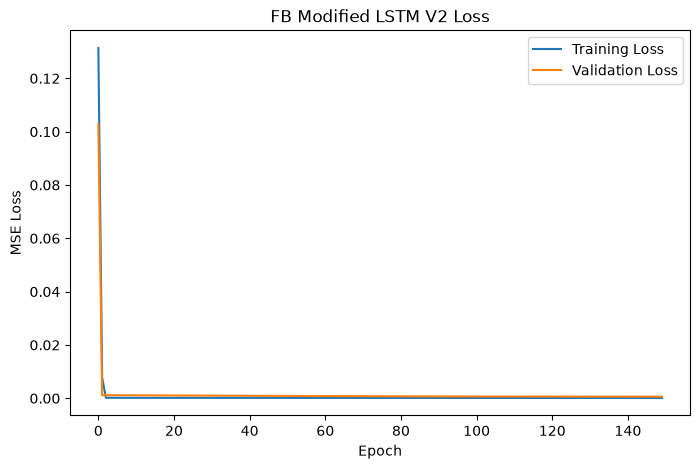

In [38]:
# Plot FB Modified V2 Loss

plt.figure(figsize=(8, 5))
plt.plot(history_modified_v2_fb.history["loss"], label="Training Loss")
plt.plot(history_modified_v2_fb.history["val_loss"], label="Validation Loss")
plt.title("FB Modified LSTM V2 Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Berdasarkan grafik loss Modified LSTM V2 pada saham FB, training loss dan validation loss mengalami penurunan yang sangat tajam pada epoch awal. Setelah beberapa epoch, kedua loss mulai stabil pada nilai yang jauh lebih rendah.

Pada hasil akhir, Modified LSTM V2 memperoleh final training loss sebesar 0.000109 dan final validation loss sebesar 0.000621. Nilai validation loss ini lebih rendah dibandingkan baseline FB dan modified LSTM pertama, sehingga Modified LSTM V2 menunjukkan peningkatan performa pada validation set.

Meskipun masih terdapat gap antara training loss dan validation loss, model ini tetap memberikan hasil terbaik pada evaluasi test set. Oleh karena itu, Modified LSTM V2 digunakan sebagai model hasil tuning untuk saham FB.

In [39]:
def build_modified_lstm_v2_ibm(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    model.add(LSTM(units=40, activation="relu"))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [40]:
# Modified LSTM V2 for IBM

modified_v2_ibm = build_modified_lstm_v2_ibm((X_train_ibm.shape[1], X_train_ibm.shape[2]))
modified_v2_ibm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 40)             │         6,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,761 (26.41 KB)

 Trainable params: 6,761 (26.41 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Early Stopping for IBM Modified V2

early_stop_v2_ibm = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=1e-8,
    restore_best_weights=True
)

In [42]:
# Train Modified LSTM V2 for IBM

modified_v2_ibm = build_modified_lstm_v2_ibm((X_train_ibm.shape[1], X_train_ibm.shape[2]))

history_modified_v2_ibm = modified_v2_ibm.fit(
    X_train_ibm,
    y_train_ibm,
    validation_data=(X_val_ibm, y_val_ibm),
    epochs=120,
    batch_size=32,
    callbacks=[early_stop_v2_ibm],
    verbose=1
)

Epoch 1/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0069 - val_loss: 1.9213e-04
Epoch 2/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1134e-05 - val_loss: 1.6743e-04
Epoch 3/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9399e-05 - val_loss: 1.6451e-04
Epoch 4/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9690e-05 - val_loss: 1.6437e-04
Epoch 5/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0040e-05 - val_loss: 1.6428e-04
Epoch 6/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0111e-05 - val_loss: 1.6347e-04
Epoch 7/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9942e-05 - val_loss: 1.6098e-04
Epoch 8/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9575e-05 - val_loss: 1.5841e-04
Epoch 9/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9173e-05 - val_loss: 1.5486e-04
Epoch 10/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.8381e-05 - val_loss: 1.5300e-04
Epoch 11/120
406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

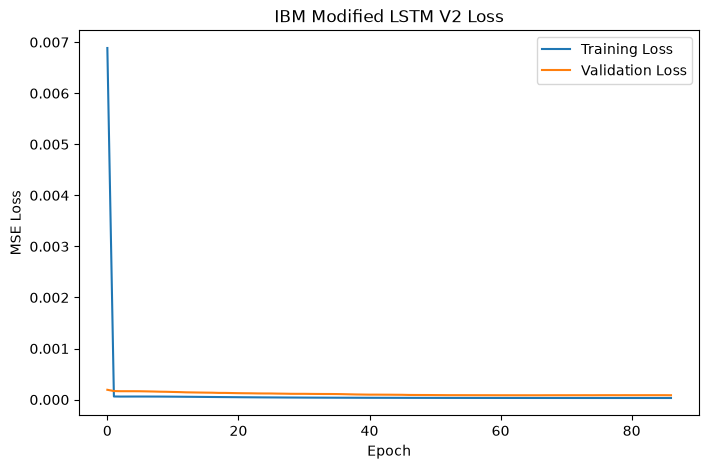

In [43]:
# Plot IBM Modified V2 Loss

plt.figure(figsize=(8, 5))
plt.plot(history_modified_v2_ibm.history["loss"], label="Training Loss")
plt.plot(history_modified_v2_ibm.history["val_loss"], label="Validation Loss")
plt.title("IBM Modified LSTM V2 Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

Berdasarkan grafik loss Modified LSTM V2 pada saham IBM, training loss dan validation loss berada pada nilai yang rendah dan relatif stabil. Training loss berada di sekitar 2.9e-05, sedangkan validation loss berada di sekitar 8.5e-05. Hal ini menunjukkan bahwa model mampu mempelajari pola data IBM dengan cukup stabil.

Model tidak berjalan sampai epoch maksimum karena menggunakan EarlyStopping. Training berhenti lebih awal karena validation loss tidak lagi menunjukkan perbaikan yang signifikan dalam beberapa epoch. Kondisi ini menunjukkan bahwa EarlyStopping bekerja sesuai tujuan, yaitu menghentikan training ketika performa pada validation set sudah tidak membaik.

Meskipun validation loss lebih tinggi dibandingkan training loss, gap tersebut masih relatif stabil. Oleh karena itu, Modified LSTM V2 tetap layak digunakan sebagai model hasil tuning dan akan dibandingkan dengan baseline menggunakan RMSE, MAE, dan MAPE pada test set.

In [44]:
# Overfitting Check Function

def check_overfitting(history, model_name, stock_name):
    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    final_train_loss = train_loss[-1]
    final_val_loss = val_loss[-1]
    best_val_loss = min(val_loss)
    best_epoch = val_loss.index(best_val_loss) + 1
    
    gap = final_val_loss - final_train_loss
    gap_ratio = final_val_loss / final_train_loss
    
    if final_val_loss > final_train_loss and gap_ratio > 2:
        status = "Indication of overfitting"
    elif final_train_loss > final_val_loss and final_train_loss > 0.01:
        status = "Indication of underfitting"
    else:
        status = "No serious overfitting"
    
    return {
        "Stock": stock_name,
        "Model": model_name,
        "Final Train Loss": final_train_loss,
        "Final Validation Loss": final_val_loss,
        "Best Validation Loss": best_val_loss,
        "Best Epoch": best_epoch,
        "Loss Gap": gap,
        "Gap Ratio": gap_ratio,
        "Overfitting Status": status
    }

overfit_results = pd.DataFrame([
    check_overfitting(history_baseline_fb, "Baseline LSTM", "FB"),
    check_overfitting(history_modified_fb, "Modified LSTM", "FB"),
    check_overfitting(history_modified_v2_fb, "Modified LSTM V2", "FB"),
    check_overfitting(history_baseline_ibm, "Baseline LSTM", "IBM"),
    check_overfitting(history_modified_ibm, "Modified LSTM", "IBM"),
    check_overfitting(history_modified_v2_ibm, "Modified LSTM V2", "IBM")
])

overfit_results

,Stock,Model,Final Train Loss,Final Validation Loss,Best Validation Loss,Best Epoch,Loss Gap,Gap Ratio,Overfitting Status
0,FB,Baseline LSTM,0.000178,0.001165,0.001165,50,0.000987,6.542245,Indication of overfitting
1,FB,Modified LSTM,0.001991,0.001213,0.001144,4,-0.000778,0.609155,No serious overfitting
2,FB,Modified LSTM V2,0.000109,0.000621,0.000621,150,0.000512,5.684526,Indication of overfitting
3,IBM,Baseline LSTM,0.000032,0.000087,0.000085,39,0.000055,2.706518,Indication of overfitting
4,IBM,Modified LSTM,0.000086,0.000209,0.000128,42,0.000124,2.444002,Indication of overfitting
5,IBM,Modified LSTM V2,0.000031,0.000085,0.000085,67,0.000054,2.718340,Indication of overfitting


### Training Behavior and Overfitting Check

Tabel overfitting check digunakan sebagai analisis tambahan untuk melihat perbandingan antara training loss dan validation loss pada setiap model. Analisis ini membantu melihat apakah terdapat gap antara performa model pada train set dan validation set.

Berdasarkan hasil tersebut, beberapa model menunjukkan validation loss yang lebih tinggi dibandingkan training loss. Hal ini wajar pada data time series karena model biasanya lebih mudah mempelajari train set dibandingkan data validation yang berada pada periode waktu berbeda.

Pada saham FB, Modified LSTM V2 tetap menunjukkan gap antara training loss dan validation loss, tetapi validation loss yang diperoleh lebih rendah dibandingkan baseline dan modified model pertama. Pada saham IBM, Modified LSTM V2 juga memiliki validation loss yang sedikit lebih baik dibandingkan baseline.

Oleh karena itu, tabel ini digunakan sebagai analisis tambahan terhadap perilaku training, bukan sebagai satu-satunya dasar pemilihan model. Penentuan model terbaik tetap dilakukan berdasarkan evaluasi pada test set menggunakan RMSE, MAE, dan MAPE.

## 1d. Model Evaluation

Pada bagian ini dilakukan evaluasi terhadap baseline LSTM, modified LSTM, dan Modified LSTM V2 pada test set. Test set yang digunakan merupakan periode satu tahun terakhir, sehingga data ini tidak digunakan pada proses training maupun validation.

Metrik evaluasi yang digunakan adalah RMSE, MAE, dan MAPE. RMSE digunakan untuk melihat besar error dengan penalti lebih besar pada kesalahan prediksi yang tinggi. MAE menunjukkan rata-rata selisih absolut antara nilai aktual dan prediksi. MAPE menunjukkan rata-rata persentase error terhadap nilai aktual.

Karena model dilatih menggunakan data yang sudah dinormalisasi, hasil prediksi perlu dikembalikan terlebih dahulu ke skala harga asli menggunakan inverse transform dari MinMaxScaler.

In [45]:
# Evaluation Function

def evaluate_lstm_model(model, X_test, y_test, scaler):
    y_pred_scaled = model.predict(X_test)
    
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred = scaler.inverse_transform(y_pred_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
    
    return rmse, mae, mape, y_actual, y_pred

In [46]:
# FB Evaluation

fb_baseline_rmse, fb_baseline_mae, fb_baseline_mape, fb_actual, fb_baseline_pred = evaluate_lstm_model(
    baseline_fb, X_test_fb, y_test_fb, fb_scaler
)

fb_modified_rmse, fb_modified_mae, fb_modified_mape, _, fb_modified_pred = evaluate_lstm_model(
    modified_fb, X_test_fb, y_test_fb, fb_scaler
)

fb_modified_v2_rmse, fb_modified_v2_mae, fb_modified_v2_mape, _, fb_modified_v2_pred = evaluate_lstm_model(
    modified_v2_fb, X_test_fb, y_test_fb, fb_scaler
)


# IBM Evaluation

ibm_baseline_rmse, ibm_baseline_mae, ibm_baseline_mape, ibm_actual, ibm_baseline_pred = evaluate_lstm_model(
    baseline_ibm, X_test_ibm, y_test_ibm, ibm_scaler
)

ibm_modified_rmse, ibm_modified_mae, ibm_modified_mape, _, ibm_modified_pred = evaluate_lstm_model(
    modified_ibm, X_test_ibm, y_test_ibm, ibm_scaler
)

ibm_modified_v2_rmse, ibm_modified_v2_mae, ibm_modified_v2_mape, _, ibm_modified_v2_pred = evaluate_lstm_model(
    modified_v2_ibm, X_test_ibm, y_test_ibm, ibm_scaler
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [47]:
# Evaluation Result Table

evaluation_result = pd.DataFrame({
    "Stock": ["FB", "FB", "FB", "IBM", "IBM", "IBM"],
    "Model": [
        "Baseline LSTM", "Modified LSTM", "Modified LSTM V2",
        "Baseline LSTM", "Modified LSTM", "Modified LSTM V2"
    ],
    "RMSE": [
        fb_baseline_rmse, fb_modified_rmse, fb_modified_v2_rmse,
        ibm_baseline_rmse, ibm_modified_rmse, ibm_modified_v2_rmse
    ],
    "MAE": [
        fb_baseline_mae, fb_modified_mae, fb_modified_v2_mae,
        ibm_baseline_mae, ibm_modified_mae, ibm_modified_v2_mae
    ],
    "MAPE (%)": [
        fb_baseline_mape, fb_modified_mape, fb_modified_v2_mape,
        ibm_baseline_mape, ibm_modified_mape, ibm_modified_v2_mape
    ]
})

evaluation_result

,Stock,Model,RMSE,MAE,MAPE (%)
0,FB,Baseline LSTM,5.549302,3.890852,2.103762
1,FB,Modified LSTM,5.595039,4.320164,2.316825
2,FB,Modified LSTM V2,4.057168,2.788925,1.511659
3,IBM,Baseline LSTM,2.674839,1.785442,1.373415
4,IBM,Modified LSTM,3.111014,2.058484,1.572655
5,IBM,Modified LSTM V2,2.652227,1.709225,1.317668


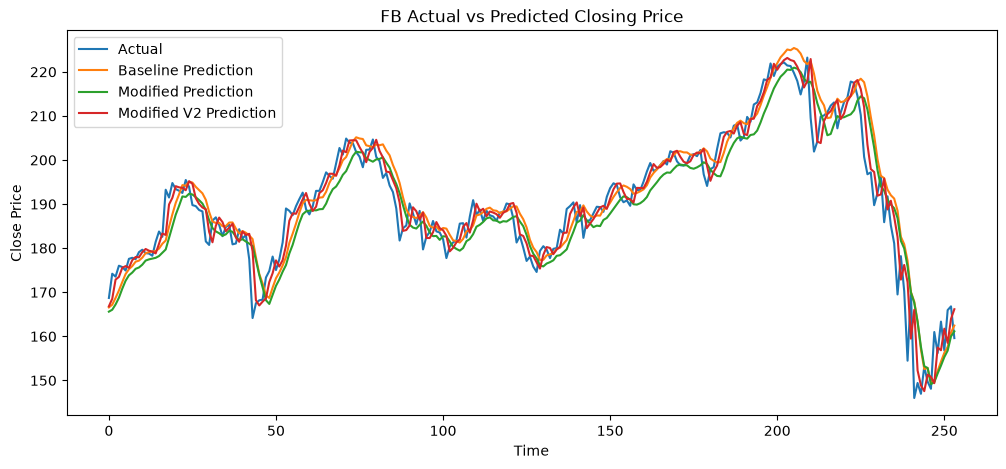

In [48]:
# FB Actual vs Predicted

plt.figure(figsize=(12, 5))
plt.plot(fb_actual, label="Actual")
plt.plot(fb_baseline_pred, label="Baseline Prediction")
plt.plot(fb_modified_pred, label="Modified Prediction")
plt.plot(fb_modified_v2_pred, label="Modified V2 Prediction")

plt.title("FB Actual vs Predicted Closing Price")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

### Actual vs Predicted Result for FB

Pada saham FB, grafik actual vs predicted menunjukkan bahwa model LSTM mampu mengikuti pola utama harga penutupan aktual pada test set satu tahun terakhir. Modified LSTM V2 terlihat paling dekat dengan pola aktual dibandingkan baseline LSTM dan modified model pertama.

Berdasarkan hasil evaluasi numerik, Modified LSTM V2 memberikan performa terbaik pada saham FB. Model ini memperoleh RMSE sebesar 4.057168, MAE sebesar 2.788925, dan MAPE sebesar 1.511659%. Nilai tersebut lebih rendah dibandingkan baseline LSTM dan modified LSTM pertama, sehingga Modified LSTM V2 lebih akurat dalam memprediksi harga penutupan saham FB pada test set.

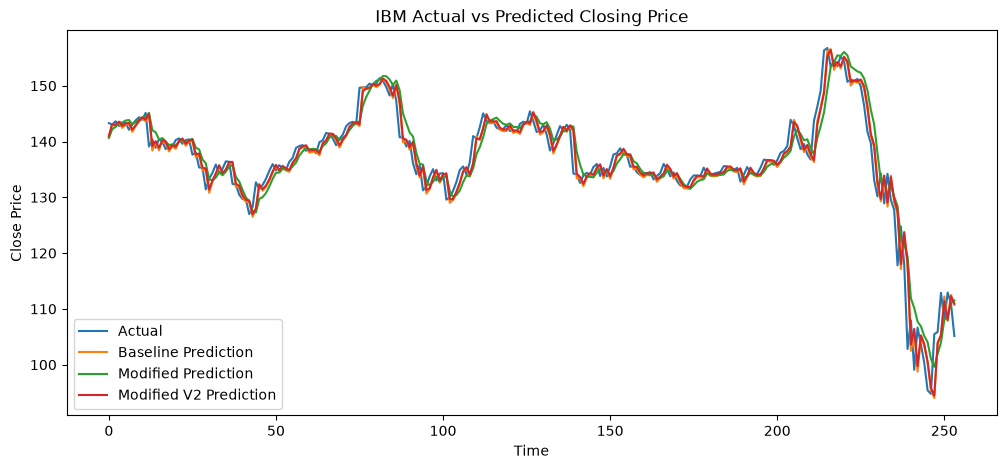

In [49]:
# IBM Actual vs Predicted

plt.figure(figsize=(12, 5))
plt.plot(ibm_actual, label="Actual")
plt.plot(ibm_baseline_pred, label="Baseline Prediction")
plt.plot(ibm_modified_pred, label="Modified Prediction")
plt.plot(ibm_modified_v2_pred, label="Modified V2 Prediction")

plt.title("IBM Actual vs Predicted Closing Price")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

### Actual vs Predicted Result for IBM

Pada saham IBM, grafik actual vs predicted menunjukkan bahwa baseline LSTM dan Modified LSTM V2 sama-sama mampu mengikuti pola pergerakan harga aktual dengan cukup baik. Namun, Modified LSTM V2 menghasilkan nilai error yang paling rendah pada test set.

Berdasarkan hasil evaluasi numerik, Modified LSTM V2 memberikan performa terbaik pada saham IBM. Model ini memperoleh RMSE sebesar 2.652227, MAE sebesar 1.709225, dan MAPE sebesar 1.317668%. Nilai tersebut lebih rendah dibandingkan baseline LSTM dan modified LSTM pertama, sehingga Modified LSTM V2 dipilih sebagai model terbaik untuk saham IBM.

### Evaluation Summary

Berdasarkan hasil evaluasi pada test set satu tahun terakhir, Modified LSTM V2 memberikan performa terbaik pada saham FB dan IBM.

Pada saham FB, baseline LSTM memperoleh RMSE sebesar 5.549302, MAE sebesar 3.890852, dan MAPE sebesar 2.103762%. Modified LSTM pertama memperoleh RMSE sebesar 5.595039, MAE sebesar 4.320164, dan MAPE sebesar 2.316825%. Setelah dilakukan tuning lanjutan, Modified LSTM V2 memperoleh hasil terbaik dengan RMSE sebesar 4.057168, MAE sebesar 2.788925, dan MAPE sebesar 1.511659%.

Pada saham IBM, baseline LSTM memperoleh RMSE sebesar 2.674839, MAE sebesar 1.785442, dan MAPE sebesar 1.373415%. Modified LSTM pertama memperoleh RMSE sebesar 3.111014, MAE sebesar 2.058484, dan MAPE sebesar 1.572655%. Modified LSTM V2 memberikan hasil terbaik dengan RMSE sebesar 2.652227, MAE sebesar 1.709225, dan MAPE sebesar 1.317668%.

Karena RMSE, MAE, dan MAPE merupakan metrik error, nilai yang lebih kecil menunjukkan performa yang lebih baik. Dengan demikian, Modified LSTM V2 dipilih sebagai model terbaik untuk prediksi harga penutupan saham FB dan IBM.